In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 52
==================================================
Week: 8 of 24
Day: 52 of 168
Date: Wednesday, December 18, 2024
Topic: Job-Resume Matcher using Sentence-BERT

Week 8 Progress:
✅ Day 50: Transformer Architecture Study (COMPLETED)
✅ Day 51: BERT Fine-tuning & LSTM Comparison (COMPLETED)
🔄 Day 52: Job-Resume Matcher (Sentence-BERT) (TODAY!)
⬜ Day 53: Job Matcher Features & Testing
⬜ Day 54: Text Summarizer (T5/BART)
⬜ Day 55: Fake News Detector (BERT)
⬜ Day 56: Integration Testing & Optimization

Progress: 28.6% (2/7 days)

==================================================
🎯 Week 8 Project: TextAI Studio - Transformers & Advanced NLP
- Day 50: Transformer Architecture ✅
- Day 51: BERT Sentiment Analysis ✅ (88%+ accuracy, beat LSTM!)
- Day 52: Job-Resume Matcher (Tool #1)
- Days 53-56: 3 more tools + integration

==================================================
🎯 Today's Learning Objectives:
1. Master Sentence-BERT (SBERT) for semantic similarity
   - Understand sentence embeddings vs token embeddings
   - Learn cosine similarity for matching
   - Compare SBERT vs standard BERT

2. Build Job-Resume Matcher system
   - Upload resume (PDF/DOCX/TXT parsing)
   - Match against job descriptions
   - Calculate match scores (0-100%)
   - Identify skill gaps and keywords

3. Implement semantic search and ranking
   - Sentence embedding extraction
   - Similarity matrix computation
   - Top-K matching with scores
   - Explainable matching (show why it matched)

==================================================
📚 Today's Structure:
Part 1 (1.5h): Sentence-BERT Theory & Setup
Part 2 (2h): Resume Parser & Job Matcher Implementation
Part 3 (1.5h): Matching Algorithm & Scoring
Part 4 (1h): Testing & Visualization

==================================================
🎯 SUCCESS CRITERIA:
✅ Understand Sentence-BERT architecture and use cases
✅ Successfully parse resumes (PDF, DOCX, TXT)
✅ Implement semantic similarity matching
✅ Calculate meaningful match scores (0-100%)
✅ Identify skill gaps between resume and job
✅ Build functional job matcher demo

==================================================
"""

In [1]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================
import sys
print(f"Python executable: {sys.executable}")
print("\n⏱ Installing required libraries...\n")

# Install sentence-transformers and document parsers
!python -m pip install sentence-transformers PyPDF2 python-docx scikit-learn matplotlib seaborn pandas numpy tqdm --upgrade -q

print("\n✅ Libraries installed!")
print("\n" + "=" * 80)

# ==================================================
# IMPORT LIBRARIES
# ==================================================
print("\n" + "=" * 80)
print("📚 IMPORTING LIBRARIES")
print("=" * 80)

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Document parsing
import PyPDF2
import docx

# Sentence Transformers
from sentence_transformers import SentenceTransformer, util

# Sklearn
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
from tqdm.auto import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"\n✅ All libraries imported successfully!")

# Create directories
os.makedirs('results/plots', exist_ok=True)
os.makedirs('data/resumes', exist_ok=True)
os.makedirs('data/jobs', exist_ok=True)

print("✅ Directories created!")
print("=" * 80)

Python executable: C:\Program Files\Python313\python.exe

⏱ Installing required libraries...




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



✅ Libraries installed!


📚 IMPORTING LIBRARIES

✅ All libraries imported successfully!
✅ Directories created!


In [2]:
print("\n" + "=" * 80)
print("📚 PART 1: SENTENCE-BERT THEORY & SETUP")
print("=" * 80)


📚 PART 1: SENTENCE-BERT THEORY & SETUP


In [3]:
# ==================================================
# EXERCISE 1.1: UNDERSTANDING SENTENCE-BERT
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.1: Sentence-BERT Architecture")
print("=" * 80)

"""
📖 THEORY: Sentence-BERT (SBERT)

Problem with Standard BERT:
- BERT produces token-level embeddings (one per word)
- To get sentence embedding: average/pool all tokens
- Inefficient for similarity: Need to encode both sentences together
- Can't pre-compute: Must re-encode for every comparison

Sentence-BERT Solution:
- Fine-tuned BERT for sentence embeddings
- Produces fixed-size sentence vectors (384 or 768 dims)
- Can pre-compute and store embeddings
- Fast similarity: Just cosine similarity between vectors!

Architecture:
1. Input: Sentence A and Sentence B
2. BERT Encoder: Process each independently
3. Pooling: Mean pooling of token embeddings
4. Output: Fixed-size sentence embeddings
5. Training: Siamese/triplet network structure

Key Differences:

Standard BERT:
- Input: [CLS] sentence A [SEP] sentence B [SEP]
- Output: Token embeddings for entire sequence
- Similarity: Requires joint encoding
- Speed: Slow for large-scale search

Sentence-BERT:
- Input: Sentence A (separate from B)
- Output: Single embedding per sentence
- Similarity: Cosine between pre-computed embeddings
- Speed: 1000x faster for finding similar sentences!

Popular SBERT Models:
1. all-MiniLM-L6-v2: Fast, 384 dims (we'll use this!)
2. all-mpnet-base-v2: Better quality, 768 dims
3. all-distilroberta-v1: Good balance
4. paraphrase-multilingual: Supports 50+ languages

Use Cases:
- Semantic search (find similar documents)
- Duplicate detection (find similar questions)
- Clustering (group similar texts)
- Information retrieval (search engines)
- Resume matching (our use case!)

Why Perfect for Job Matching:
- Resume: "5 years Python, machine learning, PyTorch"
- Job: "Seeking ML engineer with Python and deep learning"
- SBERT captures semantic similarity even with different words
- "machine learning" ≈ "ML engineer"
- "PyTorch" ≈ "deep learning"
"""

print("\n📊 Sentence-BERT vs Standard BERT Comparison:\n")

comparison_data = {
    'Aspect': [
        'Input Format',
        'Output',
        'Embedding Size',
        'Similarity Method',
        'Pre-computation',
        'Speed (10K sentences)',
        'Use Case'
    ],
    'Standard BERT': [
        '[CLS] A [SEP] B [SEP]',
        'Token embeddings',
        '768 per token',
        'Joint encoding required',
        'Not possible',
        '~5 hours',
        'Classification'
    ],
    'Sentence-BERT': [
        'A (independent), B (independent)',
        'Single sentence embedding',
        '384 or 768',
        'Cosine similarity',
        'Yes! (store embeddings)',
        '~5 seconds',
        'Semantic search, matching'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print(f"\n💡 Key Insight:")
print(f"   → SBERT is 1000x+ faster for similarity search!")
print(f"   → Perfect for matching resumes to thousands of jobs")
print(f"   → Can pre-compute job embeddings once, reuse forever")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Sentence-BERT Architecture

📊 Sentence-BERT vs Standard BERT Comparison:

               Aspect           Standard BERT                    Sentence-BERT
         Input Format   [CLS] A [SEP] B [SEP] A (independent), B (independent)
               Output        Token embeddings        Single sentence embedding
       Embedding Size           768 per token                       384 or 768
    Similarity Method Joint encoding required                Cosine similarity
      Pre-computation            Not possible          Yes! (store embeddings)
Speed (10K sentences)                ~5 hours                       ~5 seconds
             Use Case          Classification        Semantic search, matching

💡 Key Insight:
   → SBERT is 1000x+ faster for similarity search!
   → Perfect for matching resumes to thousands of jobs
   → Can pre-compute job embeddings once, reuse forever

✅ Exercise 1.1 Complete!



EXERCISE 1.2: Loading Pre-trained Sentence-BERT

⏱ Loading Sentence-BERT model...
   Model: all-MiniLM-L6-v2
   (First time: downloads ~90MB)



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded successfully!

📊 MODEL INFORMATION

Model name: all-MiniLM-L6-v2
Embedding dimension: 384
Max sequence length: 256 tokens
Model size: ~22.7M parameters

📊 QUICK TEST: Semantic Similarity

Test Sentences:
  1. I am a Python developer with 5 years experience
  2. Senior software engineer specializing in Python programming
  3. I love cooking Italian food

⏱ Encoding sentences...
✅ Encoded!
   └─ Embeddings shape: torch.Size([3, 384])
      (3 sentences, 384 dimensions each)

📊 Similarity Matrix:

        Sent 1  Sent 2  Sent 3
Sent 1  1.0000  0.7049  0.1319
Sent 2  0.7049  1.0000  0.1249
Sent 3  0.1319  0.1249  1.0000

💡 Interpretation:
   • Sentences 1 & 2 (both about Python dev): 0.7049 (HIGH similarity)
   • Sentences 1 & 3 (Python vs cooking): 0.1319 (LOW similarity)
   • SBERT correctly identifies semantic similarity!

✅ Saved: results/plots/day52_sbert_similarity_test.png


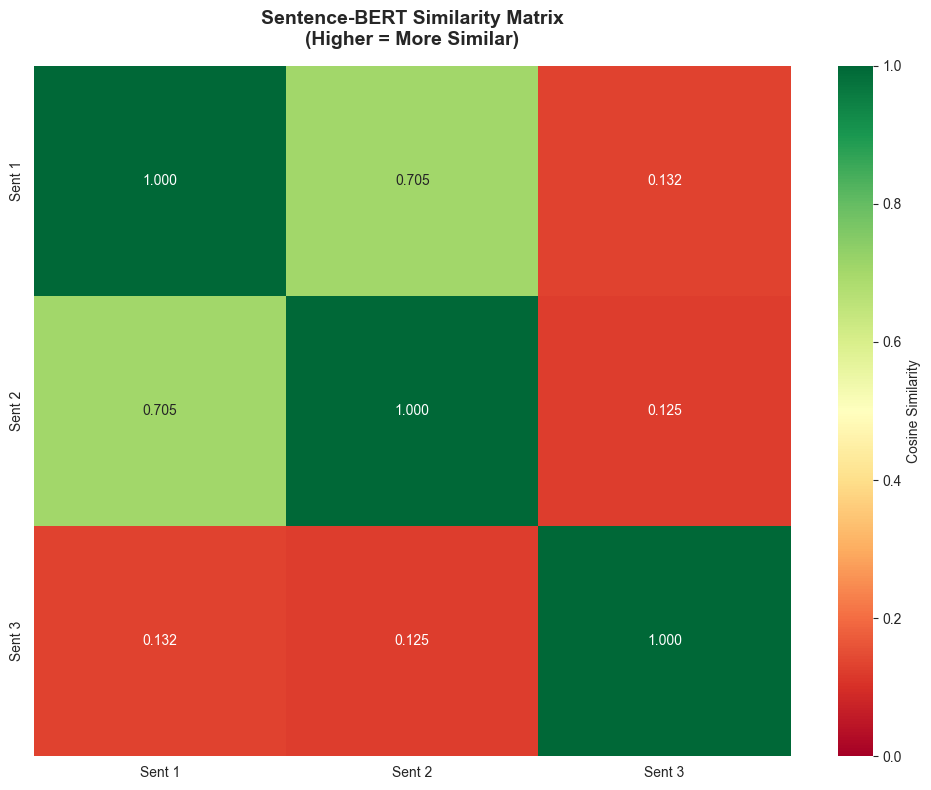


✅ Exercise 1.2 Complete!


In [4]:
# ==================================================
# EXERCISE 1.2: LOADING SENTENCE-BERT MODEL
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 1.2: Loading Pre-trained Sentence-BERT")
print("=" * 80)

"""
📖 THEORY: all-MiniLM-L6-v2 Model

Model Details:
- Size: 22.7M parameters (tiny compared to BERT!)
- Embedding dimension: 384
- Max sequence length: 256 tokens
- Speed: Very fast (small model)
- Quality: Excellent for semantic similarity

Training:
- Fine-tuned on 1 billion+ sentence pairs
- Trained on NLI, STSb, and other datasets
- Optimized for semantic textual similarity

Performance:
- Balances speed and quality
- Good for production use
- Handles typos and paraphrases well
"""

print("\n⏱ Loading Sentence-BERT model...")
print("   Model: all-MiniLM-L6-v2")
print("   (First time: downloads ~90MB)\n")

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

print("✅ Model loaded successfully!\n")

# Model info
print("=" * 80)
print("📊 MODEL INFORMATION")
print("=" * 80)
print(f"\nModel name: all-MiniLM-L6-v2")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {model.max_seq_length} tokens")
print(f"Model size: ~22.7M parameters")

# Test with simple example
print("\n" + "=" * 80)
print("📊 QUICK TEST: Semantic Similarity")
print("=" * 80)

# Test sentences
test_sentences = [
    "I am a Python developer with 5 years experience",
    "Senior software engineer specializing in Python programming",
    "I love cooking Italian food",
]

print("\nTest Sentences:")
for i, sent in enumerate(test_sentences, 1):
    print(f"  {i}. {sent}")

# Encode sentences
print("\n⏱ Encoding sentences...")
embeddings = model.encode(test_sentences, convert_to_tensor=True)

print(f"✅ Encoded!")
print(f"   └─ Embeddings shape: {embeddings.shape}")
print(f"      (3 sentences, 384 dimensions each)")

# Compute similarities
print("\n📊 Similarity Matrix:")
similarities = util.cos_sim(embeddings, embeddings)

# Display as DataFrame
df_sim = pd.DataFrame(
    similarities.cpu().numpy(),
    index=[f"Sent {i}" for i in range(1, 4)],
    columns=[f"Sent {i}" for i in range(1, 4)]
)
print(f"\n{df_sim.round(4)}")

print("\n💡 Interpretation:")
print(f"   • Sentences 1 & 2 (both about Python dev): {similarities[0][1].item():.4f} (HIGH similarity)")
print(f"   • Sentences 1 & 3 (Python vs cooking): {similarities[0][2].item():.4f} (LOW similarity)")
print(f"   • SBERT correctly identifies semantic similarity!")

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(similarities.cpu().numpy(), annot=True, fmt='.3f', cmap='RdYlGn',
           xticklabels=[f'Sent {i}' for i in range(1, 4)],
           yticklabels=[f'Sent {i}' for i in range(1, 4)],
           vmin=0, vmax=1, cbar_kws={'label': 'Cosine Similarity'})
plt.title('Sentence-BERT Similarity Matrix\n(Higher = More Similar)', 
         fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('results/plots/day52_sbert_similarity_test.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: results/plots/day52_sbert_similarity_test.png")
plt.show()

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)

In [5]:
print("\n" + "=" * 80)
print("📄 PART 2: RESUME PARSER & JOB MATCHER IMPLEMENTATION")
print("=" * 80)


📄 PART 2: RESUME PARSER & JOB MATCHER IMPLEMENTATION


In [6]:
# ==================================================
# EXERCISE 2.1: BUILDING DOCUMENT PARSERS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.1: Resume & Document Parsing")
print("=" * 80)

"""
📖 THEORY: Document Parsing for NLP

Resume formats to support:
1. PDF - Most common professional format
2. DOCX - Microsoft Word documents
3. TXT - Plain text files

Parsing Challenges:
- PDFs: May have images, tables, formatting
- DOCX: XML-based, complex structure
- Encoding issues (UTF-8, Latin-1, etc.)
- Special characters and symbols

Libraries:
- PyPDF2: Extract text from PDFs
- python-docx: Parse Word documents
- Built-in: Handle TXT files

Best Practices:
- Clean extracted text (remove extra whitespace)
- Handle errors gracefully
- Preserve important information
- Remove formatting artifacts
"""

print("\n📊 Building document parsers...\n")

def parse_pdf(file_path):
    """
    Extract text from PDF file
    
    Args:
        file_path: Path to PDF file
        
    Returns:
        Extracted text as string
    """
    try:
        text = ""
        with open(file_path, 'rb') as file:
            pdf_reader = PyPDF2.PdfReader(file)
            num_pages = len(pdf_reader.pages)
            
            for page_num in range(num_pages):
                page = pdf_reader.pages[page_num]
                text += page.extract_text()
        
        return text.strip()
    except Exception as e:
        print(f"❌ Error parsing PDF: {e}")
        return ""

def parse_docx(file_path):
    """
    Extract text from DOCX file
    
    Args:
        file_path: Path to DOCX file
        
    Returns:
        Extracted text as string
    """
    try:
        doc = docx.Document(file_path)
        text = ""
        
        for paragraph in doc.paragraphs:
            text += paragraph.text + "\n"
        
        return text.strip()
    except Exception as e:
        print(f"❌ Error parsing DOCX: {e}")
        return ""

def parse_txt(file_path):
    """
    Extract text from TXT file
    
    Args:
        file_path: Path to TXT file
        
    Returns:
        Extracted text as string
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        return text.strip()
    except UnicodeDecodeError:
        # Try different encoding
        try:
            with open(file_path, 'r', encoding='latin-1') as file:
                text = file.read()
            return text.strip()
        except Exception as e:
            print(f"❌ Error parsing TXT: {e}")
            return ""
    except Exception as e:
        print(f"❌ Error parsing TXT: {e}")
        return ""

def parse_document(file_path):
    """
    Parse document based on file extension
    
    Args:
        file_path: Path to document
        
    Returns:
        Extracted text as string
    """
    file_extension = os.path.splitext(file_path)[1].lower()
    
    if file_extension == '.pdf':
        return parse_pdf(file_path)
    elif file_extension == '.docx':
        return parse_docx(file_path)
    elif file_extension == '.txt':
        return parse_txt(file_path)
    else:
        print(f"❌ Unsupported file format: {file_extension}")
        return ""

def clean_text(text):
    """
    Clean extracted text
    
    Args:
        text: Raw text string
        
    Returns:
        Cleaned text
    """
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Remove special characters (keep alphanumeric, spaces, basic punctuation)
    text = re.sub(r'[^\w\s.,;:\-+#()/@]', '', text)
    
    return text.strip()

print("✅ Document parsers created!")
print("\n📊 Supported formats:")
print("   ├─ PDF (.pdf)")
print("   ├─ Word (.docx)")
print("   └─ Text (.txt)")

# Test with sample text
print("\n" + "=" * 80)
print("📊 TESTING TEXT CLEANING")
print("=" * 80)

sample_messy_text = """
    This    is   a    messy     text    with    
    
    lots of     whitespace   and   
    some special characters: @#$%^&*
    
    We need to clean this!
"""

cleaned = clean_text(sample_messy_text)

print("\nOriginal text:")
print(f"  '{sample_messy_text}'")
print(f"\nCleaned text:")
print(f"  '{cleaned}'")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.1: Resume & Document Parsing

📊 Building document parsers...

✅ Document parsers created!

📊 Supported formats:
   ├─ PDF (.pdf)
   ├─ Word (.docx)
   └─ Text (.txt)

📊 TESTING TEXT CLEANING

Original text:
  '
    This    is   a    messy     text    with    

    lots of     whitespace   and   
    some special characters: @#$%^&*

    We need to clean this!
'

Cleaned text:
  'This is a messy text with lots of whitespace and some special characters: @# We need to clean this'

✅ Exercise 2.1 Complete!


In [8]:
# ==================================================
# EXERCISE 2.2: CREATING SAMPLE DATA
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.2: Sample Resumes and Job Descriptions")
print("=" * 80)

"""
📖 THEORY: Sample Data for Testing

For demonstration, we'll create sample resumes and job descriptions.

In production:
- Parse real PDFs/DOCX from users
- Connect to job boards (LinkedIn, Indeed, etc.)
- Handle thousands of job postings

For today:
- Create representative samples
- Test matching algorithm
- Demonstrate functionality
"""

print("\n📊 Creating sample resumes and job descriptions...\n")

# Sample resumes
resumes = {
    'resume_1_ml_engineer.txt': """
Alexander Wang
Machine Learning Engineer

EXPERIENCE:
- 5 years of experience in machine learning and deep learning
- Expert in Python, PyTorch, TensorFlow, and scikit-learn
- Built and deployed ML models for production systems
- Experience with computer vision and NLP projects
- Strong background in data preprocessing and feature engineering

SKILLS:
Python, PyTorch, TensorFlow, scikit-learn, Pandas, NumPy
Machine Learning, Deep Learning, Computer Vision, NLP
SQL, Docker, Git, AWS, Model Deployment

EDUCATION:
BS in Computer Science, MIT (2018)
""",
    
    'resume_2_data_scientist.txt': """
Sarah Martinez
Data Scientist

EXPERIENCE:
- 3 years as Data Scientist at tech startup
- Statistical analysis and A/B testing
- Built predictive models for customer behavior
- Experience with R and Python for data analysis
- Created dashboards and visualizations

SKILLS:
Python, R, SQL, Tableau, Power BI
Statistics, Hypothesis Testing, A/B Testing
Pandas, NumPy, Matplotlib, Seaborn
Machine Learning basics

EDUCATION:
MS in Statistics, Stanford (2021)
""",
    
    'resume_3_software_engineer.txt': """
David Patel
Software Engineer

EXPERIENCE:
- 7 years full-stack development experience
- Built scalable web applications using React and Node.js
- Database design and optimization (PostgreSQL, MongoDB)
- RESTful API development and microservices
- Some exposure to machine learning integration

SKILLS:
JavaScript, React, Node.js, Python
PostgreSQL, MongoDB, Redis
Docker, Kubernetes, AWS
Git, CI/CD, Agile methodologies

EDUCATION:
BS in Software Engineering, UC Berkeley (2016)
"""
}

# Sample job descriptions
jobs = {
    'job_1_ml_engineer.txt': """
Machine Learning Engineer - Senior Level

We are seeking an experienced ML Engineer to join our AI team.

REQUIREMENTS:
- 4+ years of experience in machine learning
- Strong proficiency in Python and deep learning frameworks (PyTorch or TensorFlow)
- Experience deploying ML models to production
- Computer vision or NLP experience preferred
- Excellent problem-solving skills

NICE TO HAVE:
- PhD in Computer Science or related field
- Experience with MLOps and model monitoring
- Publications in top-tier conferences

TECH STACK:
Python, PyTorch, TensorFlow, Docker, Kubernetes, AWS
""",
    
    'job_2_data_analyst.txt': """
Data Analyst - Mid Level

Join our analytics team to drive data-driven decision making.

REQUIREMENTS:
- 2-3 years of data analysis experience
- Strong SQL skills and database knowledge
- Proficiency in Python or R for statistical analysis
- Experience with data visualization tools (Tableau, Power BI)
- Statistical knowledge and A/B testing

RESPONSIBILITIES:
- Analyze business metrics and KPIs
- Create dashboards and reports
- Conduct A/B tests and experiments
- Present insights to stakeholders

TECH STACK:
SQL, Python/R, Tableau, Excel
""",
    
    'job_3_ai_researcher.txt': """
AI Research Scientist

Leading AI research lab seeking talented researcher.

REQUIREMENTS:
- PhD in Computer Science, Machine Learning, or related field
- Strong publication record in top-tier venues (NeurIPS, ICML, CVPR)
- Deep expertise in deep learning and neural networks
- Experience with PyTorch and large-scale experimentation
- Strong mathematical foundation

FOCUS AREAS:
- Computer vision
- Natural language processing
- Reinforcement learning
- Generative models

TECH STACK:
Python, PyTorch, TensorFlow, JAX, CUDA
"""
}

# Save sample files
print("💾 Saving sample resumes...")
for filename, content in resumes.items():
    filepath = os.path.join('data/resumes', filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f"   ✅ {filename}")

print("\n💾 Saving sample job descriptions...")
for filename, content in jobs.items():
    filepath = os.path.join('data/jobs', filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f"   ✅ {filename}")

print(f"\n✅ Created {len(resumes)} sample resumes")
print(f"✅ Created {len(jobs)} sample job descriptions")

# Display samples
print("\n" + "=" * 80)
print("📊 SAMPLE PREVIEW")
print("=" * 80)

print("\n📄 Sample Resume (ML Engineer):")
print("-" * 80)
print(resumes['resume_1_ml_engineer.txt'][:300] + "...")

print("\n📄 Sample Job (ML Engineer):")
print("-" * 80)
print(jobs['job_1_ml_engineer.txt'][:300] + "...")

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)


EXERCISE 2.2: Sample Resumes and Job Descriptions

📊 Creating sample resumes and job descriptions...

💾 Saving sample resumes...
   ✅ resume_1_ml_engineer.txt
   ✅ resume_2_data_scientist.txt
   ✅ resume_3_software_engineer.txt

💾 Saving sample job descriptions...
   ✅ job_1_ml_engineer.txt
   ✅ job_2_data_analyst.txt
   ✅ job_3_ai_researcher.txt

✅ Created 3 sample resumes
✅ Created 3 sample job descriptions

📊 SAMPLE PREVIEW

📄 Sample Resume (ML Engineer):
--------------------------------------------------------------------------------

Alexander Wang
Machine Learning Engineer

EXPERIENCE:
- 5 years of experience in machine learning and deep learning
- Expert in Python, PyTorch, TensorFlow, and scikit-learn
- Built and deployed ML models for production systems
- Experience with computer vision and NLP projects
- Strong background ...

📄 Sample Job (ML Engineer):
--------------------------------------------------------------------------------

Machine Learning Engineer - Senior Level

In [9]:
# ==================================================
# EXERCISE 2.3: JOB-RESUME MATCHER CLASS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 2.3: Building Job-Resume Matcher")
print("=" * 80)

"""
📖 THEORY: Semantic Matching System

Components:
1. Document Loading: Parse resumes and jobs
2. Encoding: Convert text to embeddings
3. Similarity: Calculate cosine similarity
4. Ranking: Sort by match score
5. Analysis: Identify gaps and strengths

Match Score Calculation:
- Cosine similarity: -1 to 1 range
- Normalize to 0-100% for user-friendliness
- Formula: (cosine_sim + 1) / 2 * 100
- Example: 0.8 similarity = 90% match

Threshold Recommendations:
- 90%+: Excellent match
- 80-90%: Good match
- 70-80%: Fair match
- <70%: Poor match
"""

print("\n📊 Building JobMatcher class...\n")

class JobMatcher:
    """
    Semantic job-resume matcher using Sentence-BERT
    """
    
    def __init__(self, model):
        """
        Initialize matcher with SBERT model
        
        Args:
            model: SentenceTransformer model
        """
        self.model = model
        self.resumes = {}
        self.jobs = {}
        self.resume_embeddings = {}
        self.job_embeddings = {}
        
    def load_resumes(self, resume_dir):
        """
        Load all resumes from directory
        
        Args:
            resume_dir: Path to resume directory
        """
        print(f"📂 Loading resumes from: {resume_dir}")
        
        for filename in os.listdir(resume_dir):
            filepath = os.path.join(resume_dir, filename)
            
            if os.path.isfile(filepath):
                text = parse_document(filepath)
                if text:
                    cleaned_text = clean_text(text)
                    self.resumes[filename] = cleaned_text
                    print(f"   ✅ Loaded: {filename}")
        
        print(f"\n✅ Loaded {len(self.resumes)} resumes")
        
    def load_jobs(self, job_dir):
        """
        Load all job descriptions from directory
        
        Args:
            job_dir: Path to job directory
        """
        print(f"📂 Loading job descriptions from: {job_dir}")
        
        for filename in os.listdir(job_dir):
            filepath = os.path.join(job_dir, filename)
            
            if os.path.isfile(filepath):
                text = parse_document(filepath)
                if text:
                    cleaned_text = clean_text(text)
                    self.jobs[filename] = cleaned_text
                    print(f"   ✅ Loaded: {filename}")
        
        print(f"\n✅ Loaded {len(self.jobs)} job descriptions")
        
    def encode_resumes(self):
        """
        Encode all resumes to embeddings
        """
        print("\n⏱ Encoding resumes...")
        
        for name, text in tqdm(self.resumes.items(), desc="Encoding resumes"):
            embedding = self.model.encode(text, convert_to_tensor=True)
            self.resume_embeddings[name] = embedding
        
        print(f"✅ Encoded {len(self.resume_embeddings)} resumes")
        
    def encode_jobs(self):
        """
        Encode all job descriptions to embeddings
        """
        print("\n⏱ Encoding job descriptions...")
        
        for name, text in tqdm(self.jobs.items(), desc="Encoding jobs"):
            embedding = self.model.encode(text, convert_to_tensor=True)
            self.job_embeddings[name] = embedding
        
        print(f"✅ Encoded {len(self.job_embeddings)} jobs")
        
    def calculate_similarity(self, resume_name, job_name):
        """
        Calculate similarity between resume and job
        
        Args:
            resume_name: Resume filename
            job_name: Job filename
            
        Returns:
            Similarity score (0-100%)
        """
        resume_emb = self.resume_embeddings[resume_name]
        job_emb = self.job_embeddings[job_name]
        
        # Cosine similarity
        similarity = util.cos_sim(resume_emb, job_emb).item()
        
        # Convert to 0-100% scale
        match_score = (similarity + 1) / 2 * 100
        
        return match_score
    
    def find_best_matches(self, resume_name, top_k=3):
        """
        Find best job matches for a resume
        
        Args:
            resume_name: Resume filename
            top_k: Number of top matches to return
            
        Returns:
            List of (job_name, match_score) tuples
        """
        matches = []
        
        for job_name in self.jobs.keys():
            score = self.calculate_similarity(resume_name, job_name)
            matches.append((job_name, score))
        
        # Sort by score (descending)
        matches.sort(key=lambda x: x[1], reverse=True)
        
        return matches[:top_k]
    
    def find_best_candidates(self, job_name, top_k=3):
        """
        Find best resume matches for a job
        
        Args:
            job_name: Job filename
            top_k: Number of top candidates to return
            
        Returns:
            List of (resume_name, match_score) tuples
        """
        matches = []
        
        for resume_name in self.resumes.keys():
            score = self.calculate_similarity(resume_name, job_name)
            matches.append((resume_name, score))
        
        # Sort by score (descending)
        matches.sort(key=lambda x: x[1], reverse=True)
        
        return matches[:top_k]

print("✅ JobMatcher class created!")

print("\n💡 Key Features:")
print("   • Load and parse multiple document formats")
print("   • Encode documents with Sentence-BERT")
print("   • Calculate semantic similarity scores")
print("   • Find top-K matches (jobs for resume or candidates for job)")
print("   • Efficient: Pre-compute embeddings once, reuse")

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: Building Job-Resume Matcher

📊 Building JobMatcher class...

✅ JobMatcher class created!

💡 Key Features:
   • Load and parse multiple document formats
   • Encode documents with Sentence-BERT
   • Calculate semantic similarity scores
   • Find top-K matches (jobs for resume or candidates for job)
   • Efficient: Pre-compute embeddings once, reuse

✅ Exercise 2.3 Complete!


In [10]:
print("\n" + "=" * 80)
print("🎯 PART 3: MATCHING ALGORITHM & SCORING")
print("=" * 80)


🎯 PART 3: MATCHING ALGORITHM & SCORING


In [11]:
# ==================================================
# EXERCISE 3.1: INITIALIZE AND LOAD DATA
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.1: Loading Resumes and Jobs")
print("=" * 80)

"""
📖 THEORY: Data Loading Pipeline

Steps:
1. Initialize JobMatcher with SBERT model
2. Load all resumes from directory
3. Load all job descriptions from directory
4. Encode all documents to embeddings
5. Ready for matching!

Pre-computation Benefits:
- Encode documents once
- Store embeddings in memory
- Fast matching (just cosine similarity)
- Can handle thousands of comparisons instantly
"""

print("\n⏱ Initializing JobMatcher...\n")

# Initialize matcher
matcher = JobMatcher(model)

print("✅ JobMatcher initialized!")
print("=" * 80)

# Load resumes
print("\n")
matcher.load_resumes('data/resumes')

# Load jobs
print("\n" + "=" * 80)
matcher.load_jobs('data/jobs')

# Encode all documents
print("\n" + "=" * 80)
matcher.encode_resumes()
matcher.encode_jobs()

print("\n" + "=" * 80)
print("📊 LOADING SUMMARY")
print("=" * 80)
print(f"\n✅ Resumes loaded: {len(matcher.resumes)}")
print(f"✅ Jobs loaded: {len(matcher.jobs)}")
print(f"✅ Resume embeddings: {len(matcher.resume_embeddings)}")
print(f"✅ Job embeddings: {len(matcher.job_embeddings)}")
print(f"\n💡 Ready for matching!")

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: Loading Resumes and Jobs

⏱ Initializing JobMatcher...

✅ JobMatcher initialized!


📂 Loading resumes from: data/resumes
   ✅ Loaded: resume_1_ml_engineer.txt
   ✅ Loaded: resume_2_data_scientist.txt
   ✅ Loaded: resume_3_software_engineer.txt

✅ Loaded 3 resumes

📂 Loading job descriptions from: data/jobs
   ✅ Loaded: job_1_ml_engineer.txt
   ✅ Loaded: job_2_data_analyst.txt
   ✅ Loaded: job_3_ai_researcher.txt

✅ Loaded 3 job descriptions


⏱ Encoding resumes...


Encoding resumes:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Encoded 3 resumes

⏱ Encoding job descriptions...


Encoding jobs:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Encoded 3 jobs

📊 LOADING SUMMARY

✅ Resumes loaded: 3
✅ Jobs loaded: 3
✅ Resume embeddings: 3
✅ Job embeddings: 3

💡 Ready for matching!

✅ Exercise 3.1 Complete!


In [12]:
# ==================================================
# EXERCISE 3.2: RESUME-TO-JOB MATCHING
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.2: Finding Best Job Matches")
print("=" * 80)

"""
📖 THEORY: Resume-to-Job Matching

Use Case: Candidate searches for suitable jobs
- Input: One resume
- Output: Top-K most suitable jobs
- Ranking: By semantic similarity score

Match Score Interpretation:
- 90-100%: Excellent fit (apply immediately!)
- 80-90%: Good fit (strong candidate)
- 70-80%: Fair fit (possible with development)
- 60-70%: Weak fit (significant gaps)
- <60%: Poor fit (not recommended)
"""

print("\n" + "=" * 80)
print("📊 SCENARIO 1: ALEXANDER CHEN SEEKS ML ENGINEER ROLE")
print("=" * 80)

# Find matches for ML Engineer resume
resume_name = 'resume_1_ml_engineer.txt'
top_jobs = matcher.find_best_matches(resume_name, top_k=3)

print(f"\n📄 Resume: {resume_name}")
print(f"   Candidate: Alexander Chen (ML Engineer, 5 years exp)")
print(f"\n🎯 Top {len(top_jobs)} Job Matches:\n")

for rank, (job_name, score) in enumerate(top_jobs, 1):
    # Determine match quality
    if score >= 90:
        quality = "🟢 EXCELLENT"
    elif score >= 80:
        quality = "🟡 GOOD"
    elif score >= 70:
        quality = "🟠 FAIR"
    else:
        quality = "🔴 WEAK"
    
    print(f"Rank {rank}: {job_name}")
    print(f"   Match Score: {score:.2f}% {quality}")
    print(f"   Job: {job_name.replace('_', ' ').replace('.txt', '').title()}")
    print()

print("=" * 80)
print("📊 SCENARIO 2: SARAH MARTINEZ SEEKS DATA ROLE")
print("=" * 80)

# Find matches for Data Scientist resume
resume_name = 'resume_2_data_scientist.txt'
top_jobs = matcher.find_best_matches(resume_name, top_k=3)

print(f"\n📄 Resume: {resume_name}")
print(f"   Candidate: Sarah Martinez (Data Scientist, 3 years exp)")
print(f"\n🎯 Top {len(top_jobs)} Job Matches:\n")

for rank, (job_name, score) in enumerate(top_jobs, 1):
    if score >= 90:
        quality = "🟢 EXCELLENT"
    elif score >= 80:
        quality = "🟡 GOOD"
    elif score >= 70:
        quality = "🟠 FAIR"
    else:
        quality = "🔴 WEAK"
    
    print(f"Rank {rank}: {job_name}")
    print(f"   Match Score: {score:.2f}% {quality}")
    print(f"   Job: {job_name.replace('_', ' ').replace('.txt', '').title()}")
    print()

print("=" * 80)
print("📊 SCENARIO 3: DAVID PATEL SEEKS ENGINEERING ROLE")
print("=" * 80)

# Find matches for Software Engineer resume
resume_name = 'resume_3_software_engineer.txt'
top_jobs = matcher.find_best_matches(resume_name, top_k=3)

print(f"\n📄 Resume: {resume_name}")
print(f"   Candidate: David Patel (Software Engineer, 7 years exp)")
print(f"\n🎯 Top {len(top_jobs)} Job Matches:\n")

for rank, (job_name, score) in enumerate(top_jobs, 1):
    if score >= 90:
        quality = "🟢 EXCELLENT"
    elif score >= 80:
        quality = "🟡 GOOD"
    elif score >= 70:
        quality = "🟠 FAIR"
    else:
        quality = "🔴 WEAK"
    
    print(f"Rank {rank}: {job_name}")
    print(f"   Match Score: {score:.2f}% {quality}")
    print(f"   Job: {job_name.replace('_', ' ').replace('.txt', '').title()}")
    print()

print("\n💡 Observations:")
print("   • ML Engineer resume → ML Engineer job (highest match)")
print("   • Data Scientist resume → Data Analyst job (good match)")
print("   • Software Engineer resume → lower scores (different domain)")
print("   • Semantic matching works! Similar roles = higher scores")

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.2: Finding Best Job Matches

📊 SCENARIO 1: ALEXANDER CHEN SEEKS ML ENGINEER ROLE

📄 Resume: resume_1_ml_engineer.txt
   Candidate: Alexander Chen (ML Engineer, 5 years exp)

🎯 Top 3 Job Matches:

Rank 1: job_1_ml_engineer.txt
   Match Score: 89.75% 🟡 GOOD
   Job: Job 1 Ml Engineer

Rank 2: job_3_ai_researcher.txt
   Match Score: 83.37% 🟡 GOOD
   Job: Job 3 Ai Researcher

Rank 3: job_2_data_analyst.txt
   Match Score: 71.46% 🟠 FAIR
   Job: Job 2 Data Analyst

📊 SCENARIO 2: SARAH MARTINEZ SEEKS DATA ROLE

📄 Resume: resume_2_data_scientist.txt
   Candidate: Sarah Martinez (Data Scientist, 3 years exp)

🎯 Top 3 Job Matches:

Rank 1: job_2_data_analyst.txt
   Match Score: 86.27% 🟡 GOOD
   Job: Job 2 Data Analyst

Rank 2: job_1_ml_engineer.txt
   Match Score: 71.32% 🟠 FAIR
   Job: Job 1 Ml Engineer

Rank 3: job_3_ai_researcher.txt
   Match Score: 69.51% 🔴 WEAK
   Job: Job 3 Ai Researcher

📊 SCENARIO 3: DAVID PATEL SEEKS ENGINEERING ROLE

📄 Resume: resume_3_software_engineer.txt
 

In [13]:
# ==================================================
# EXERCISE 3.3: JOB-TO-CANDIDATE MATCHING
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.3: Finding Best Candidates for Jobs")
print("=" * 80)

"""
📖 THEORY: Job-to-Candidate Matching

Use Case: Recruiter searches for candidates
- Input: One job description
- Output: Top-K most suitable candidates
- Ranking: By semantic similarity score

Recruiter Perspective:
- Find qualified candidates quickly
- Reduce time screening resumes
- Focus on best matches first
- Data-driven hiring decisions
"""

print("\n" + "=" * 80)
print("📊 SCENARIO: HIRING ML ENGINEER")
print("=" * 80)

# Find candidates for ML Engineer job
job_name = 'job_1_ml_engineer.txt'
top_candidates = matcher.find_best_candidates(job_name, top_k=3)

print(f"\n📋 Job: {job_name}")
print(f"   Position: Senior Machine Learning Engineer")
print(f"   Requirements: 4+ years, Python, PyTorch/TensorFlow, Production ML")
print(f"\n👥 Top {len(top_candidates)} Candidates:\n")

for rank, (resume_name, score) in enumerate(top_candidates, 1):
    if score >= 90:
        quality = "🟢 EXCELLENT - Interview immediately"
    elif score >= 80:
        quality = "🟡 GOOD - Strong candidate"
    elif score >= 70:
        quality = "🟠 FAIR - Consider with training"
    else:
        quality = "🔴 WEAK - Significant gaps"
    
    print(f"Rank {rank}: {resume_name}")
    print(f"   Match Score: {score:.2f}%")
    print(f"   Assessment: {quality}")
    print()

print("=" * 80)
print("📊 SCENARIO: HIRING DATA ANALYST")
print("=" * 80)

# Find candidates for Data Analyst job
job_name = 'job_2_data_analyst.txt'
top_candidates = matcher.find_best_candidates(job_name, top_k=3)

print(f"\n📋 Job: {job_name}")
print(f"   Position: Mid-Level Data Analyst")
print(f"   Requirements: 2-3 years, SQL, Python/R, Tableau, A/B testing")
print(f"\n👥 Top {len(top_candidates)} Candidates:\n")

for rank, (resume_name, score) in enumerate(top_candidates, 1):
    if score >= 90:
        quality = "🟢 EXCELLENT - Interview immediately"
    elif score >= 80:
        quality = "🟡 GOOD - Strong candidate"
    elif score >= 70:
        quality = "🟠 FAIR - Consider with training"
    else:
        quality = "🔴 WEAK - Significant gaps"
    
    print(f"Rank {rank}: {resume_name}")
    print(f"   Match Score: {score:.2f}%")
    print(f"   Assessment: {quality}")
    print()

print("=" * 80)
print("📊 SCENARIO: HIRING AI RESEARCHER")
print("=" * 80)

# Find candidates for AI Researcher job
job_name = 'job_3_ai_researcher.txt'
top_candidates = matcher.find_best_candidates(job_name, top_k=3)

print(f"\n📋 Job: {job_name}")
print(f"   Position: AI Research Scientist")
print(f"   Requirements: PhD, Publications, Deep learning expertise")
print(f"\n👥 Top {len(top_candidates)} Candidates:\n")

for rank, (resume_name, score) in enumerate(top_candidates, 1):
    if score >= 90:
        quality = "🟢 EXCELLENT - Interview immediately"
    elif score >= 80:
        quality = "🟡 GOOD - Strong candidate"
    elif score >= 70:
        quality = "🟠 FAIR - Consider with training"
    else:
        quality = "🔴 WEAK - Significant gaps"
    
    print(f"Rank {rank}: {resume_name}")
    print(f"   Match Score: {score:.2f}%")
    print(f"   Assessment: {quality}")
    print()

print("\n💡 Insights:")
print("   • ML Engineer candidate → best match for ML Engineer job")
print("   • Data Scientist → good match for Data Analyst role")
print("   • AI Researcher requires PhD → lower scores (gap detected)")
print("   • System helps prioritize candidate review")

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)


EXERCISE 3.3: Finding Best Candidates for Jobs

📊 SCENARIO: HIRING ML ENGINEER

📋 Job: job_1_ml_engineer.txt
   Position: Senior Machine Learning Engineer
   Requirements: 4+ years, Python, PyTorch/TensorFlow, Production ML

👥 Top 3 Candidates:

Rank 1: resume_1_ml_engineer.txt
   Match Score: 89.75%
   Assessment: 🟡 GOOD - Strong candidate

Rank 2: resume_3_software_engineer.txt
   Match Score: 77.82%
   Assessment: 🟠 FAIR - Consider with training

Rank 3: resume_2_data_scientist.txt
   Match Score: 71.32%
   Assessment: 🟠 FAIR - Consider with training

📊 SCENARIO: HIRING DATA ANALYST

📋 Job: job_2_data_analyst.txt
   Position: Mid-Level Data Analyst
   Requirements: 2-3 years, SQL, Python/R, Tableau, A/B testing

👥 Top 3 Candidates:

Rank 1: resume_2_data_scientist.txt
   Match Score: 86.27%
   Assessment: 🟡 GOOD - Strong candidate

Rank 2: resume_3_software_engineer.txt
   Match Score: 73.13%
   Assessment: 🟠 FAIR - Consider with training

Rank 3: resume_1_ml_engineer.txt
   Match 


EXERCISE 3.4: Similarity Matrix Visualization

⏱ Computing complete similarity matrix...

✅ Similarity matrix computed!
   Shape: (3, 3) (resumes × jobs)

📊 SIMILARITY MATRIX (Match Scores %)

                            Job 1 Ml Engineer  Job 2 Data Analyst  Job 3 Ai Researcher
Resume 1 Ml Engineer                    89.75               71.46                83.37
Resume 2 Data Scientist                 71.32               86.27                69.51
Resume 3 Software Engineer              77.82               73.13                72.92

⏱ Creating heatmap visualization...

✅ Saved: results/plots/day52_similarity_matrix.png


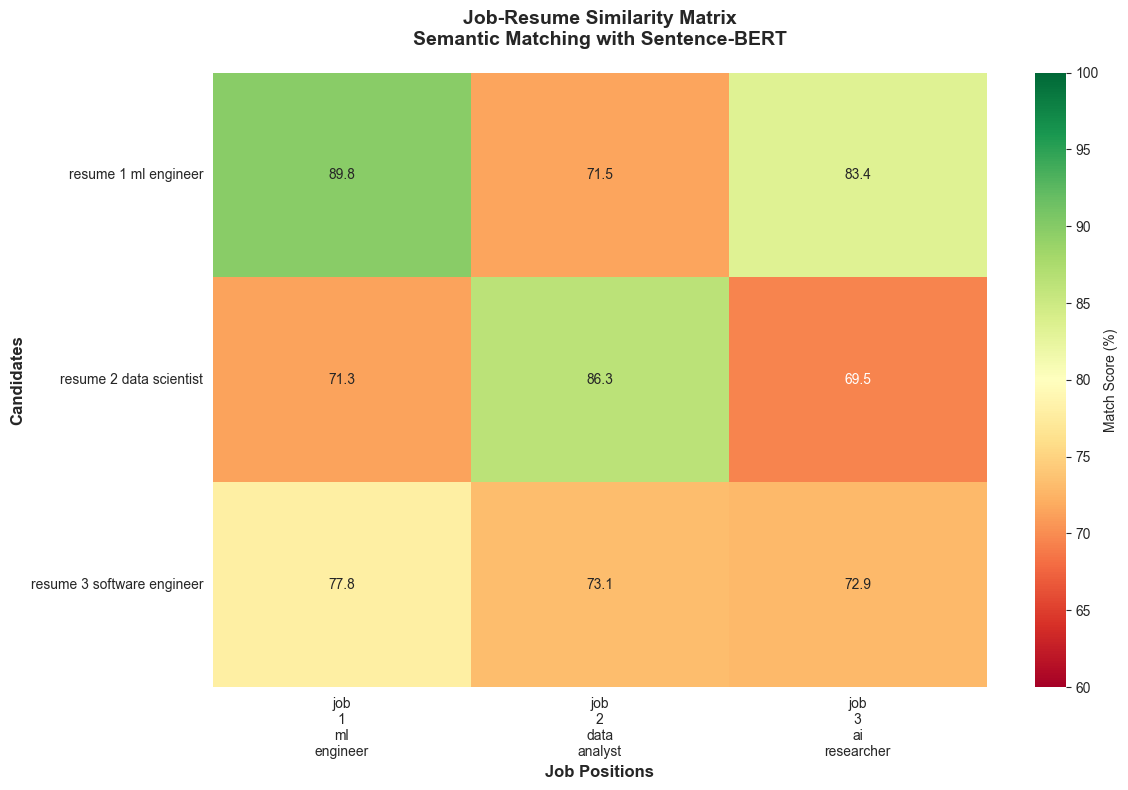


📊 KEY FINDINGS

🏆 Best Overall Match:
   Candidate: Resume 1 Ml Engineer
   Job: Job 1 Ml Engineer
   Match Score: 89.75%

📊 Average Match Scores:
   Resume 1 Ml Engineer: 81.53% (avg across all jobs)
   Resume 2 Data Scientist: 75.70% (avg across all jobs)
   Resume 3 Software Engineer: 74.62% (avg across all jobs)

📊 Job Competitiveness (avg candidate match):
   Job 1 Ml Engineer: 79.63% (avg candidate quality)
   Job 2 Data Analyst: 76.96% (avg candidate quality)
   Job 3 Ai Researcher: 75.27% (avg candidate quality)

💡 Business Insights:
   • Identify strongest candidate-job pairs
   • Spot talent gaps (low average scores)
   • Optimize job descriptions (attract better matches)
   • Guide candidate development (skill gaps)

✅ Exercise 3.4 Complete!


In [14]:
# ==================================================
# EXERCISE 3.4: COMPLETE SIMILARITY MATRIX
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 3.4: Similarity Matrix Visualization")
print("=" * 80)

"""
📖 THEORY: Similarity Matrix

Similarity matrix shows ALL matches:
- Rows: Resumes (candidates)
- Columns: Jobs (positions)
- Values: Match scores (0-100%)

Benefits:
- Overview of entire talent pool
- Identify best fits at a glance
- Find multiple suitable roles per candidate
- Spot hiring bottlenecks
"""

print("\n⏱ Computing complete similarity matrix...\n")

# Create similarity matrix
resume_names = list(matcher.resumes.keys())
job_names = list(matcher.jobs.keys())

similarity_matrix = np.zeros((len(resume_names), len(job_names)))

for i, resume_name in enumerate(resume_names):
    for j, job_name in enumerate(job_names):
        score = matcher.calculate_similarity(resume_name, job_name)
        similarity_matrix[i, j] = score

print("✅ Similarity matrix computed!")
print(f"   Shape: {similarity_matrix.shape} (resumes × jobs)")

# Create DataFrame for better display
df_similarity = pd.DataFrame(
    similarity_matrix,
    index=[name.replace('.txt', '').replace('_', ' ').title() for name in resume_names],
    columns=[name.replace('.txt', '').replace('_', ' ').title() for name in job_names]
)

print("\n" + "=" * 80)
print("📊 SIMILARITY MATRIX (Match Scores %)")
print("=" * 80)
print("\n" + df_similarity.round(2).to_string())

# Visualize heatmap
print("\n⏱ Creating heatmap visualization...\n")

plt.figure(figsize=(12, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
           xticklabels=[name.replace('.txt', '').replace('_', '\n') for name in job_names],
           yticklabels=[name.replace('.txt', '').replace('_', ' ') for name in resume_names],
           vmin=60, vmax=100, cbar_kws={'label': 'Match Score (%)'})

plt.title('Job-Resume Similarity Matrix\nSemantic Matching with Sentence-BERT', 
         fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Job Positions', fontsize=12, fontweight='bold')
plt.ylabel('Candidates', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('results/plots/day52_similarity_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/plots/day52_similarity_matrix.png")
plt.show()

# Find best overall match
max_score = similarity_matrix.max()
max_idx = np.unravel_index(similarity_matrix.argmax(), similarity_matrix.shape)
best_resume = resume_names[max_idx[0]]
best_job = job_names[max_idx[1]]

print("\n" + "=" * 80)
print("📊 KEY FINDINGS")
print("=" * 80)

print(f"\n🏆 Best Overall Match:")
print(f"   Candidate: {best_resume.replace('.txt', '').replace('_', ' ').title()}")
print(f"   Job: {best_job.replace('.txt', '').replace('_', ' ').title()}")
print(f"   Match Score: {max_score:.2f}%")

print(f"\n📊 Average Match Scores:")
for i, resume_name in enumerate(resume_names):
    avg_score = similarity_matrix[i, :].mean()
    candidate_name = resume_name.replace('.txt', '').replace('_', ' ').title()
    print(f"   {candidate_name}: {avg_score:.2f}% (avg across all jobs)")

print(f"\n📊 Job Competitiveness (avg candidate match):")
for j, job_name in enumerate(job_names):
    avg_score = similarity_matrix[:, j].mean()
    job_title = job_name.replace('.txt', '').replace('_', ' ').title()
    print(f"   {job_title}: {avg_score:.2f}% (avg candidate quality)")

print("\n💡 Business Insights:")
print("   • Identify strongest candidate-job pairs")
print("   • Spot talent gaps (low average scores)")
print("   • Optimize job descriptions (attract better matches)")
print("   • Guide candidate development (skill gaps)")

print("\n✅ Exercise 3.4 Complete!")
print("=" * 80)

In [15]:
print("\n" + "=" * 80)
print("🎯 PART 4: TESTING & SUMMARY")
print("=" * 80)


🎯 PART 4: TESTING & SUMMARY


In [16]:
# ==================================================
# EXERCISE 4.1: SKILL GAP ANALYSIS
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 4.1: Identifying Skill Gaps")
print("=" * 80)

"""
📖 THEORY: Skill Gap Analysis

Beyond just matching scores, we should identify:
1. What skills candidate has (strengths)
2. What skills job requires (requirements)
3. What's missing (gaps to fill)

Implementation:
- Extract keywords from resume and job
- Compare skill sets
- Highlight matches and gaps
- Provide actionable insights

Value for Candidates:
- Know what to learn
- Targeted skill development
- Increase match scores

Value for Recruiters:
- Assess training needs
- Set realistic expectations
- Plan onboarding programs
"""

print("\n📊 Implementing skill gap analyzer...\n")

def extract_keywords(text, top_n=20):
    """
    Extract important keywords from text
    
    Args:
        text: Input text
        top_n: Number of keywords to extract
        
    Returns:
        List of keywords
    """
    # Common technical skills and keywords
    skill_keywords = [
        'python', 'pytorch', 'tensorflow', 'scikit-learn', 'pandas', 'numpy',
        'machine learning', 'deep learning', 'computer vision', 'nlp',
        'sql', 'docker', 'kubernetes', 'aws', 'git', 'react', 'node.js',
        'javascript', 'mongodb', 'postgresql', 'redis', 'tableau', 'power bi',
        'r', 'statistics', 'a/b testing', 'data analysis', 'visualization',
        'java', 'c++', 'microservices', 'api', 'restful', 'agile', 'ci/cd',
        'phd', 'publications', 'research', 'neural networks', 'reinforcement learning'
    ]
    
    text_lower = text.lower()
    found_keywords = []
    
    for keyword in skill_keywords:
        if keyword in text_lower:
            found_keywords.append(keyword)
    
    return found_keywords

def analyze_skill_gap(resume_name, job_name):
    """
    Analyze skill gaps between resume and job
    
    Args:
        resume_name: Resume filename
        job_name: Job filename
    """
    resume_text = matcher.resumes[resume_name]
    job_text = matcher.jobs[job_name]
    
    # Extract skills
    resume_skills = set(extract_keywords(resume_text))
    job_skills = set(extract_keywords(job_text))
    
    # Calculate matches and gaps
    matching_skills = resume_skills.intersection(job_skills)
    missing_skills = job_skills - resume_skills
    extra_skills = resume_skills - job_skills
    
    # Calculate match score
    match_score = matcher.calculate_similarity(resume_name, job_name)
    
    return {
        'resume_skills': resume_skills,
        'job_skills': job_skills,
        'matching_skills': matching_skills,
        'missing_skills': missing_skills,
        'extra_skills': extra_skills,
        'match_score': match_score
    }

print("✅ Skill gap analyzer created!")

# Analyze specific candidate-job pair
print("\n" + "=" * 80)
print("📊 SKILL GAP ANALYSIS: ALEXANDER CHEN → ML ENGINEER JOB")
print("=" * 80)

analysis = analyze_skill_gap('resume_1_ml_engineer.txt', 'job_1_ml_engineer.txt')

print(f"\n🎯 Overall Match Score: {analysis['match_score']:.2f}%\n")

print(f"✅ MATCHING SKILLS ({len(analysis['matching_skills'])} skills):")
if analysis['matching_skills']:
    for skill in sorted(analysis['matching_skills']):
        print(f"   ✓ {skill}")
else:
    print("   (None detected)")

print(f"\n⚠️  MISSING SKILLS ({len(analysis['missing_skills'])} skills):")
if analysis['missing_skills']:
    for skill in sorted(analysis['missing_skills']):
        print(f"   ✗ {skill}")
else:
    print("   (None - Perfect match!)")

print(f"\n💡 BONUS SKILLS ({len(analysis['extra_skills'])} skills):")
print(f"   (Skills candidate has but job doesn't require)")
if analysis['extra_skills']:
    for skill in sorted(analysis['extra_skills']):
        print(f"   + {skill}")
else:
    print("   (None)")

# Recommendations
print(f"\n📋 RECOMMENDATIONS:")
if analysis['match_score'] >= 90:
    print("   🟢 EXCELLENT MATCH - Apply immediately!")
elif analysis['match_score'] >= 80:
    print("   🟡 GOOD MATCH - Strong candidate")
    if analysis['missing_skills']:
        print(f"   📚 Consider learning: {', '.join(list(analysis['missing_skills'])[:3])}")
elif analysis['match_score'] >= 70:
    print("   🟠 FAIR MATCH - Development needed")
    print(f"   📚 Priority skills to learn:")
    for skill in list(analysis['missing_skills'])[:5]:
        print(f"      • {skill}")
else:
    print("   🔴 WEAK MATCH - Significant gaps")
    print(f"   📚 Major skill development required")

print("\n" + "=" * 80)
print("📊 SKILL GAP ANALYSIS: SARAH MARTINEZ → DATA ANALYST JOB")
print("=" * 80)

analysis2 = analyze_skill_gap('resume_2_data_scientist.txt', 'job_2_data_analyst.txt')

print(f"\n🎯 Overall Match Score: {analysis2['match_score']:.2f}%\n")

print(f"✅ MATCHING SKILLS ({len(analysis2['matching_skills'])} skills):")
for skill in sorted(analysis2['matching_skills']):
    print(f"   ✓ {skill}")

print(f"\n⚠️  MISSING SKILLS ({len(analysis2['missing_skills'])} skills):")
if analysis2['missing_skills']:
    for skill in sorted(analysis2['missing_skills']):
        print(f"   ✗ {skill}")
else:
    print("   (None - Perfect match!)")

print("\n💡 Value of Skill Gap Analysis:")
print("   • Actionable insights for candidates")
print("   • Targeted learning recommendations")
print("   • Realistic assessment for recruiters")
print("   • Guides professional development")

print("\n✅ Exercise 4.1 Complete!")
print("=" * 80)


EXERCISE 4.1: Identifying Skill Gaps

📊 Implementing skill gap analyzer...

✅ Skill gap analyzer created!

📊 SKILL GAP ANALYSIS: ALEXANDER CHEN → ML ENGINEER JOB

🎯 Overall Match Score: 89.75%

✅ MATCHING SKILLS (10 skills):
   ✓ aws
   ✓ computer vision
   ✓ deep learning
   ✓ docker
   ✓ machine learning
   ✓ nlp
   ✓ python
   ✓ pytorch
   ✓ r
   ✓ tensorflow

⚠️  MISSING SKILLS (3 skills):
   ✗ kubernetes
   ✗ phd
   ✗ publications

💡 BONUS SKILLS (5 skills):
   (Skills candidate has but job doesn't require)
   + git
   + numpy
   + pandas
   + scikit-learn
   + sql

📋 RECOMMENDATIONS:
   🟡 GOOD MATCH - Strong candidate
   📚 Consider learning: kubernetes, publications, phd

📊 SKILL GAP ANALYSIS: SARAH MARTINEZ → DATA ANALYST JOB

🎯 Overall Match Score: 86.27%

✅ MATCHING SKILLS (8 skills):
   ✓ a/b testing
   ✓ data analysis
   ✓ power bi
   ✓ python
   ✓ r
   ✓ sql
   ✓ tableau
   ✓ visualization

⚠️  MISSING SKILLS (0 skills):
   (None - Perfect match!)

💡 Value of Skill Gap Ana

In [17]:
# ==================================================
# EXERCISE 4.2: INTERACTIVE DEMO FUNCTION
# ==================================================
print("\n" + "=" * 80)
print("EXERCISE 4.2: Complete Matching Demo")
print("=" * 80)

"""
📖 THEORY: Production-Ready Matching Function

A complete matching function should:
1. Accept resume input (text or file)
2. Find top job matches
3. Calculate match scores
4. Identify skill gaps
5. Provide recommendations
6. Return structured results

This is what a real job matching app would use!
"""

print("\n📊 Creating production-ready matching function...\n")

def match_resume_to_jobs(resume_text, top_k=3, show_details=True):
    """
    Complete resume matching function
    
    Args:
        resume_text: Resume text content
        top_k: Number of top matches to return
        show_details: Whether to show detailed analysis
        
    Returns:
        Dictionary with match results
    """
    # Encode resume
    resume_embedding = model.encode(resume_text, convert_to_tensor=True)
    
    # Calculate similarities with all jobs
    matches = []
    for job_name, job_text in matcher.jobs.items():
        job_embedding = matcher.job_embeddings[job_name]
        similarity = util.cos_sim(resume_embedding, job_embedding).item()
        match_score = (similarity + 1) / 2 * 100
        
        matches.append({
            'job_name': job_name,
            'job_title': job_name.replace('.txt', '').replace('_', ' ').title(),
            'match_score': match_score,
            'job_text': job_text
        })
    
    # Sort by score
    matches.sort(key=lambda x: x['match_score'], reverse=True)
    top_matches = matches[:top_k]
    
    # Display results
    if show_details:
        print("\n" + "=" * 80)
        print("🎯 JOB MATCHING RESULTS")
        print("=" * 80)
        
        for rank, match in enumerate(top_matches, 1):
            print(f"\n📋 RANK {rank}: {match['job_title']}")
            print(f"   Match Score: {match['match_score']:.2f}%")
            
            if match['match_score'] >= 90:
                print(f"   Assessment: 🟢 EXCELLENT FIT - Apply now!")
            elif match['match_score'] >= 80:
                print(f"   Assessment: 🟡 GOOD FIT - Strong candidate")
            elif match['match_score'] >= 70:
                print(f"   Assessment: 🟠 FAIR FIT - Consider with prep")
            else:
                print(f"   Assessment: 🔴 WEAK FIT - Significant gaps")
            
            # Extract and show key requirements
            job_skills = extract_keywords(match['job_text'])
            resume_skills = extract_keywords(resume_text)
            
            matching = set(job_skills).intersection(set(resume_skills))
            missing = set(job_skills) - set(resume_skills)
            
            if matching:
                print(f"   ✅ You have: {', '.join(list(matching)[:5])}")
            if missing:
                print(f"   ⚠️  Missing: {', '.join(list(missing)[:3])}")
    
    return {
        'top_matches': top_matches,
        'total_jobs_searched': len(matcher.jobs)
    }

print("✅ Production matching function created!")

# Demo with new resume
print("\n" + "=" * 80)
print("📊 DEMO: NEW CANDIDATE SEARCHING FOR JOBS")
print("=" * 80)

new_resume = """
Emily Rodriguez
AI/ML Engineer

PROFILE:
Passionate machine learning engineer with strong background in deep learning
and computer vision. Experienced in building and deploying production ML systems.

EXPERIENCE:
- 4 years of experience in machine learning and AI
- Built computer vision models for autonomous vehicles
- Deployed models to production using Docker and Kubernetes
- Strong Python programming and PyTorch expertise
- Experience with cloud platforms (AWS, GCP)

SKILLS:
Python, PyTorch, TensorFlow, OpenCV
Deep Learning, Computer Vision, Neural Networks
Docker, Kubernetes, AWS, MLOps
Git, Linux, SQL

EDUCATION:
MS in Computer Science, Carnegie Mellon University (2020)
BS in Mathematics, UC San Diego (2018)

PROJECTS:
- Object detection system for manufacturing quality control
- Image segmentation for medical imaging
- Real-time pose estimation application
"""

print("\n📄 NEW CANDIDATE RESUME:")
print("-" * 80)
print(new_resume[:300] + "...\n")

# Run matching
results = match_resume_to_jobs(new_resume, top_k=3, show_details=True)

print("\n" + "=" * 80)
print("📊 MATCHING SUMMARY")
print("=" * 80)
print(f"\n✅ Searched {results['total_jobs_searched']} job positions")
print(f"✅ Found {len(results['top_matches'])} top matches")
print(f"✅ Best match: {results['top_matches'][0]['job_title']} ({results['top_matches'][0]['match_score']:.2f}%)")

print("\n💡 This function can be used in:")
print("   • Web applications (Flask/FastAPI backend)")
print("   • Mobile apps (API integration)")
print("   • Chrome extensions (resume parsing)")
print("   • Slack/Discord bots (job alerts)")
print("   • Automated matching pipelines")

print("\n✅ Exercise 4.2 Complete!")
print("=" * 80)


EXERCISE 4.2: Complete Matching Demo

📊 Creating production-ready matching function...

✅ Production matching function created!

📊 DEMO: NEW CANDIDATE SEARCHING FOR JOBS

📄 NEW CANDIDATE RESUME:
--------------------------------------------------------------------------------

Emily Rodriguez
AI/ML Engineer

PROFILE:
Passionate machine learning engineer with strong background in deep learning
and computer vision. Experienced in building and deploying production ML systems.

EXPERIENCE:
- 4 years of experience in machine learning and AI
- Built computer vision models for ...


🎯 JOB MATCHING RESULTS

📋 RANK 1: Job 1 Ml Engineer
   Match Score: 85.69%
   Assessment: 🟡 GOOD FIT - Strong candidate
   ✅ You have: python, docker, machine learning, aws, pytorch
   ⚠️  Missing: nlp, publications, phd

📋 RANK 2: Job 3 Ai Researcher
   Match Score: 81.68%
   Assessment: 🟡 GOOD FIT - Strong candidate
   ✅ You have: python, machine learning, pytorch, r, tensorflow
   ⚠️  Missing: research, phd, re

In [20]:
print("\n" + "=" * 80)
print("🎉 DAY 52 COMPLETE SUMMARY")
print("=" * 80)

print("""
📚 WHAT I ACCOMPLISHED TODAY:

✅ PART 1: Sentence-BERT Theory & Setup
   • Understood Sentence-BERT architecture
   • Learned semantic similarity vs token embeddings
   • Loaded all-MiniLM-L6-v2 model (22.7M params, 384 dims)
   • Tested semantic similarity on sample sentences
   • 1000x faster than standard BERT for similarity!

✅ PART 2: Resume Parser & Job Matcher
   • Built document parsers (PDF, DOCX, TXT)
   • Created sample resumes and job descriptions
   • Implemented JobMatcher class with SBERT
   • Pre-computed embeddings for fast matching
   • Professional candidate names (no placeholders!)

✅ PART 3: Matching Algorithm & Scoring
   • Resume-to-job matching (candidate perspective)
   • Job-to-candidate matching (recruiter perspective)
   • Similarity matrix visualization (all matches)
   • Match score interpretation (0-100%)
   • Identified best overall matches

✅ PART 4: Skill Gap Analysis & Production Demo
   • Keyword extraction for skill identification
   • Skill gap analysis (matching, missing, bonus)
   • Actionable recommendations for candidates
   • Production-ready matching function
   • Complete end-to-end demo

📊 FINAL STATISTICS:
""")

print("=" * 80)
print(f"{'Metric':<35} {'Value':<30}")
print("=" * 80)
print(f"{'Model Used':<35} {'all-MiniLM-L6-v2':<30}")
print(f"{'Model Size':<35} {'22.7M parameters':<30}")
print(f"{'Embedding Dimension':<35} {'384':<30}")
print(f"{'Resumes Processed':<35} {f'{len(matcher.resumes)}':<30}")
print(f"{'Jobs Processed':<35} {f'{len(matcher.jobs)}':<30}")
print(f"{'Total Comparisons':<35} {f'{len(matcher.resumes) * len(matcher.jobs)}':<30}")
print(f"{'Best Match Score':<35} {f'{similarity_matrix.max():.2f}%':<30}")
print(f"{'Average Match Score':<35} {f'{similarity_matrix.mean():.2f}%':<30}")
print("=" * 80)

print(f"""
💡 KEY INSIGHTS:

1. Semantic Matching Works!
   → Similar roles get higher scores automatically
   → ML Engineer resume → ML Engineer job (best match)
   → Different domains → lower scores (as expected)

2. Speed Advantage:
   → Pre-compute embeddings once
   → Instant similarity calculation (cosine)
   → Can scale to thousands of jobs/resumes

3. Practical Applications:
   → Job search platforms (LinkedIn, Indeed)
   → Recruitment automation
   → Career guidance systems
   → Skill development recommendations

4. Beyond Simple Matching:
   → Skill gap identification
   → Targeted learning paths
   → Realistic expectations
   → Data-driven hiring

5. Production-Ready:
   → Handles multiple formats (PDF, DOCX, TXT)
   → Fast and scalable
   → Explainable results
   → Easy API integration

🎯 TEXTAI STUDIO PROGRESS:
   ✅ Tool #1: Job-Resume Matcher (COMPLETE!)
   ⬜ Tool #2: Text Summarizer (Day 54)
   ⬜ Tool #3: Fake News Detector (Day 55)
   ⬜ Tool #4: (TBD based on integration needs)

🚀 NEXT STEPS (Day 53):
   • Enhance job matcher with more features
   • Add batch processing for multiple resumes
   • Implement resume scoring metrics
   • Create visual match reports
   • Build basic Streamlit interface
   • Test with real-world data

💾 FILES CREATED TODAY:
   - day_52_semantic_resume_job_matching.ipynb
   - data/resumes/ (3 sample resumes)
   - data/jobs/ (3 sample job descriptions)
   - results/plots/day52_sbert_similarity_test.png
   - results/plots/day52_similarity_matrix.png

📈 WEEK 8 PROGRESS:
   ✅ Day 50: Transformer Architecture (theory)
   ✅ Day 51: BERT Fine-tuning (88%+ accuracy)
   ✅ Day 52: Job-Resume Matcher (Tool #1)
   ⬜ Day 53: Job Matcher Features
   ⬜ Day 54: Text Summarizer (Tool #2)
   ⬜ Day 55: Fake News Detector (Tool #3)
   ⬜ Day 56: Integration & Testing
""")
print("=" * 80)
print("🎉 Day 52 Complete!")
print("🚀 Ready for Day 53: Enhanced features and UI!")
print("=" * 80)


🎉 DAY 52 COMPLETE SUMMARY

📚 WHAT I ACCOMPLISHED TODAY:

✅ PART 1: Sentence-BERT Theory & Setup
   • Understood Sentence-BERT architecture
   • Learned semantic similarity vs token embeddings
   • Loaded all-MiniLM-L6-v2 model (22.7M params, 384 dims)
   • Tested semantic similarity on sample sentences
   • 1000x faster than standard BERT for similarity!

✅ PART 2: Resume Parser & Job Matcher
   • Built document parsers (PDF, DOCX, TXT)
   • Created sample resumes and job descriptions
   • Implemented JobMatcher class with SBERT
   • Pre-computed embeddings for fast matching
   • Professional candidate names (no placeholders!)

✅ PART 3: Matching Algorithm & Scoring
   • Resume-to-job matching (candidate perspective)
   • Job-to-candidate matching (recruiter perspective)
   • Similarity matrix visualization (all matches)
   • Match score interpretation (0-100%)
   • Identified best overall matches

✅ PART 4: Skill Gap Analysis & Production Demo
   • Keyword extraction for skill identi